In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

In [2]:
def generate_toddler_data(start_date="2025-07-01", end_date="2025-11-18"):
    
    dates = pd.date_range(start=start_date, end=end_date, freq="D")
    np.random.seed(24353)

    # DST shift
    dst_shift = dt.datetime(2025, 11, 2)

    # Daylight: deterministic linear decrease from 15h (July) to 9.5h (Nov)
    dl_start = 15 * 60
    dl_end = 9.5 * 60
    daylight_min = np.linspace(dl_start, dl_end, len(dates))

    # Apply DST shift
    dst_index = np.where(dates == dst_shift)[0][0]
    daylight_min[dst_index:] -= 60

    # Lists for synthetic variables
    outdoor_play = []
    indoor_play = []
    meltdowns = []
    interaction_reqs = []
    nap_duration = []
    wake_times = []
    bed_times = []
    field_trip = []
    field_location = []

    for i, d in enumerate(dates):

        dl_min = daylight_min[i]
        is_after_dst = d >= dst_shift

        # Outdoor play proportional to daylight
        base_outdoor = np.random.normal(dl_min * 1.75, 20)

        if is_after_dst:
            base_outdoor *= np.random.uniform(0.25, 0.75)

        base_outdoor = max(base_outdoor, 0)
        outdoor_play.append(base_outdoor)

        # Indoor play compensates
        indoor_base = np.random.normal(20, 10) + max(0, (600 - dl_min))

        if is_after_dst:
            indoor_base *= np.random.uniform(0.07, 1.25)

        indoor_play.append(indoor_base)

        # Nap duration declines into November
        nap_base = np.random.normal(130, 10)

        if d.month == 11:
            nap_base -= np.random.uniform(80, 10)

        if is_after_dst:
            nap_base -= np.random.uniform(15, 5)

        nap_duration.append(max(nap_base, 0))

        # Meltdowns increase as outdoor play declines
        meltdown_rate = 1 + max(0, (90 - base_outdoor) / 30)

        if is_after_dst:
            meltdown_rate *= np.random.uniform(1.2, 1.4)

        meltdowns.append(max(0, int(np.random.poisson(meltdown_rate))))

        # Interaction requests rise with indoor play
        interaction_rate = 5 + indoor_base / 25

        if is_after_dst:
            interaction_rate *= 1.15

        interaction_reqs.append(int(np.random.poisson(interaction_rate)))

        # Sleep schedule
        wake_shift = -20 if is_after_dst else 0
        bed_shift = -30 if is_after_dst else 0

        wake_times.append(
            (
                dt.datetime(2025, 1, 1, 7, 0)
                + dt.timedelta(minutes=np.random.normal(wake_shift, 20))
            ).time()
        )

        bed_times.append(
            (
                dt.datetime(2025, 1, 1, 20, 0)
                + dt.timedelta(minutes=np.random.normal(bed_shift, 30))
            ).time()
        )

        # Field trips
        trip = np.random.rand() < 3 / 7
        field_trip.append(trip)

        if trip:
            field_location.append(
                np.random.choice(
                    ["Museum", "Grocery", "Library", "Park", "Aquarium"]
                )
            )
        else:
            field_location.append(None)

    df = pd.DataFrame(
        {
            "date": dates,
            "daylight_min": daylight_min,
            "outdoor_play_min": outdoor_play,
            "indoor_play_min": indoor_play,
            "meltdown_count": meltdowns,
            "interaction_requests": interaction_reqs,
            "nap_duration_min": nap_duration,
            "wake_time": wake_times,
            "bed_time": bed_times,
            "field_trip": field_trip,
            "field_location": field_location,
        }
    )

    return df

In [3]:
# Generate dataset
df = generate_toddler_data()

In [4]:
df.head()

,date,daylight_min,outdoor_play_min,indoor_play_min,meltdown_count,interaction_requests,nap_duration_min,wake_time,bed_time,field_trip,field_location
0,2025-07-01,900.000000,1599.645620,25.491298,1,6,123.522563,06:56:21.249654,20:12:39.624641,True,Park
1,2025-07-02,897.642857,1563.392635,30.870988,0,6,138.167686,07:34:00.597069,19:35:46.005877,True,Library
2,2025-07-03,895.285714,1573.208382,32.166974,0,2,115.869453,07:40:05.419323,19:46:48.873820,False,None
3,2025-07-04,892.928571,1591.088757,32.298550,0,9,136.561012,07:09:59.453681,19:51:19.660990,False,None
4,2025-07-05,890.571429,1576.616706,28.503574,0,8,127.350050,06:39:27.629475,20:15:21.645045,True,Aquarium


In [5]:
df.tail(10)

,date,daylight_min,outdoor_play_min,indoor_play_min,meltdown_count,interaction_requests,nap_duration_min,wake_time,bed_time,field_trip,field_location
131,2025-11-09,531.214286,618.219011,56.492358,3,7,53.618438,07:11:01.557974,19:07:09.072905,True,Aquarium
132,2025-11-10,528.857143,395.229882,48.394281,2,6,81.372530,06:14:39.786019,19:29:03.761570,False,None
133,2025-11-11,526.500000,638.452821,68.916029,2,11,65.611177,06:28:28.456036,18:52:44.625043,False,None
134,2025-11-12,524.142857,297.698987,46.584218,2,13,67.490097,06:08:58.728814,18:59:17.372420,False,None
135,2025-11-13,521.785714,279.346346,24.214401,2,3,56.855525,06:32:46.993915,18:25:19.397198,False,None
136,2025-11-14,519.428571,547.685157,87.112647,0,9,110.354832,06:41:51.566623,20:06:58.703708,False,None
137,2025-11-15,517.071429,428.755032,82.365086,2,7,92.295046,06:17:34.332880,18:22:09.163644,True,Library
138,2025-11-16,514.714286,302.363587,95.724906,1,7,91.040337,06:45:08.318818,19:43:22.188011,False,None
139,2025-11-17,512.357143,637.829597,33.641587,1,3,107.569801,06:36:25.490127,18:55:03.621642,False,None
140,2025-11-18,510.000000,392.425661,111.538693,1,9,78.065816,06:06:46.613240,20:08:06.483047,True,Museum


In [6]:
# Normalize variables
normalized = df.copy()

cols_to_norm = [
    "outdoor_play_min",
    "indoor_play_min",
    "meltdown_count",
    "interaction_requests",
    "nap_duration_min",
    "daylight_min",
]

for col in cols_to_norm:

    min_val = df[col].min()
    max_val = df[col].max()

    normalized[col + "_norm"] = (df[col] - min_val) / (max_val - min_val)

<Figure size 1000x800 with 0 Axes>

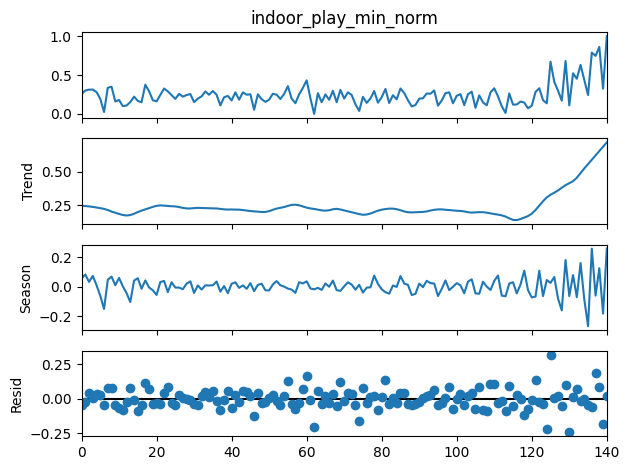

<Figure size 1000x800 with 0 Axes>

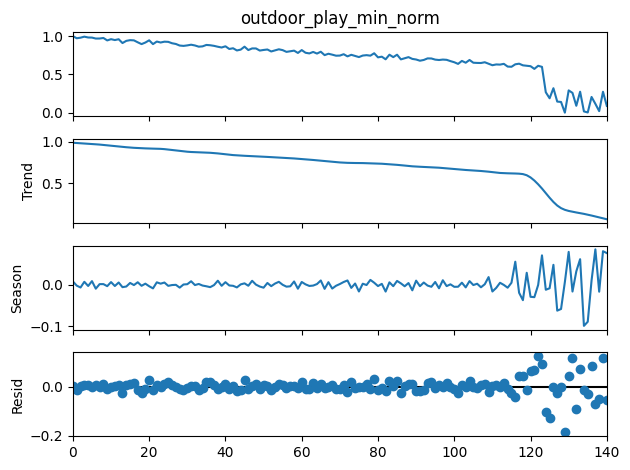

<Figure size 1000x800 with 0 Axes>

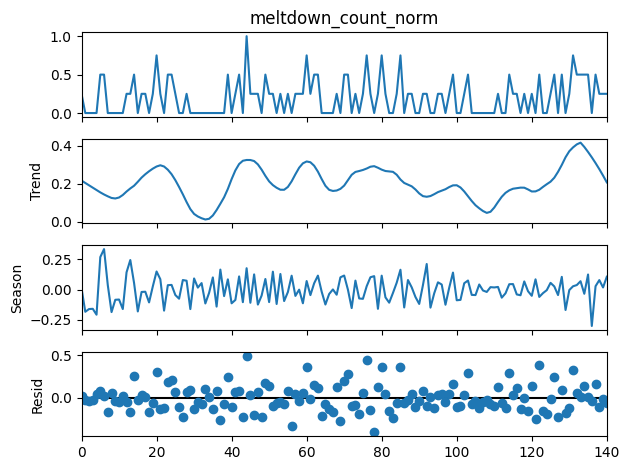

<Figure size 1000x800 with 0 Axes>

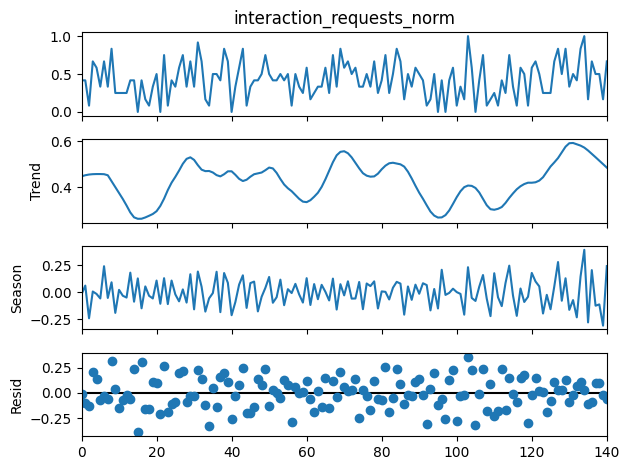

<Figure size 1000x800 with 0 Axes>

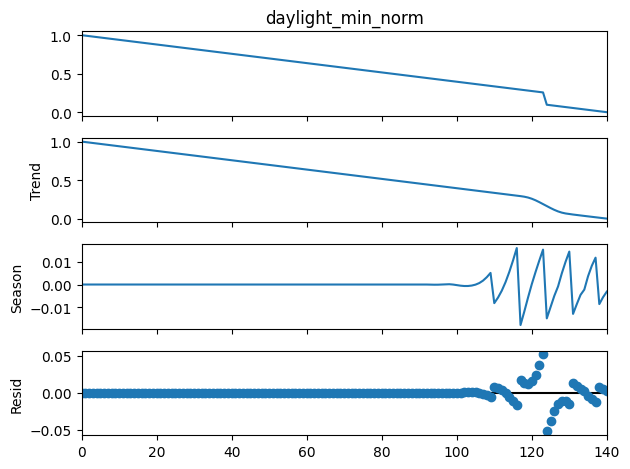

In [7]:
# STL decompositions
res_nap = STL(normalized["nap_duration_min_norm"], period=7).fit()
res_in = STL(normalized["indoor_play_min_norm"], period=7).fit()
res_out = STL(normalized["outdoor_play_min_norm"], period=7).fit()
res_melt = STL(normalized["meltdown_count_norm"], period=7).fit()
res_int = STL(normalized["interaction_requests_norm"], period=7).fit()
res_day = STL(normalized["daylight_min_norm"], period=7).fit()


# Plot decompositions
for res in [res_in, res_out, res_melt, res_int, res_day]:

    plt.figure(figsize=(10, 8))
    res.plot()
    plt.show()

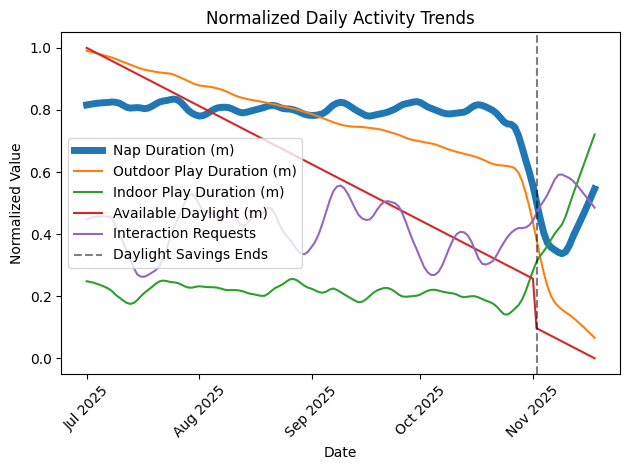

In [8]:
# Trend comparison plot
res_out = STL(normalized["outdoor_play_min_norm"], period=7).fit()
res_in = STL(normalized["indoor_play_min_norm"], period=7).fit()
res_nap = STL(normalized["nap_duration_min_norm"], period=7).fit()

res_day = normalized["daylight_min_norm"]

plt.plot(normalized["date"], res_nap.trend, label="Nap Duration (m)", linewidth=5)
plt.plot(normalized["date"], res_out.trend, label="Outdoor Play Duration (m)")
plt.plot(normalized["date"], res_in.trend, label="Indoor Play Duration (m)")
plt.plot(normalized["date"], res_day, label="Available Daylight (m)")
plt.plot(normalized["date"], res_int.trend, label="Interaction Requests")

months = pd.date_range(normalized["date"].min(), df["date"].max(), freq="MS")

plt.xticks(months, [d.strftime("%b %Y") for d in months], rotation=45)

dst_date = pd.to_datetime("2025-11-02")
plt.axvline(
    dst_date,
    color="black",
    linestyle="--",
    label="Daylight Savings Ends",
    alpha=0.5,
)

plt.title("Normalized Daily Activity Trends")
plt.xlabel("Date")
plt.ylabel("Normalized Value")

plt.legend()
plt.tight_layout()

plt.savefig("trend_analysis.png")

plt.show()

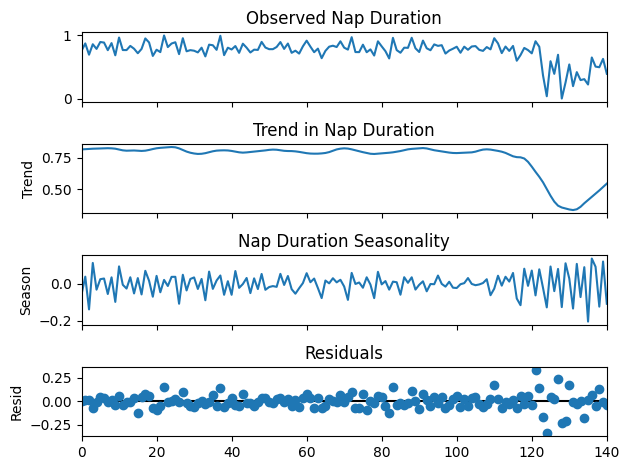

In [9]:
# Nap decomposition plot
fig = res_nap.plot()

axes = fig.axes

axes[0].set_title("Observed Nap Duration")
axes[1].set_title("Trend in Nap Duration")
axes[2].set_title("Nap Duration Seasonality")
axes[3].set_title("Residuals")

plt.tight_layout()

plt.savefig("nap_decomp.png")

plt.show()

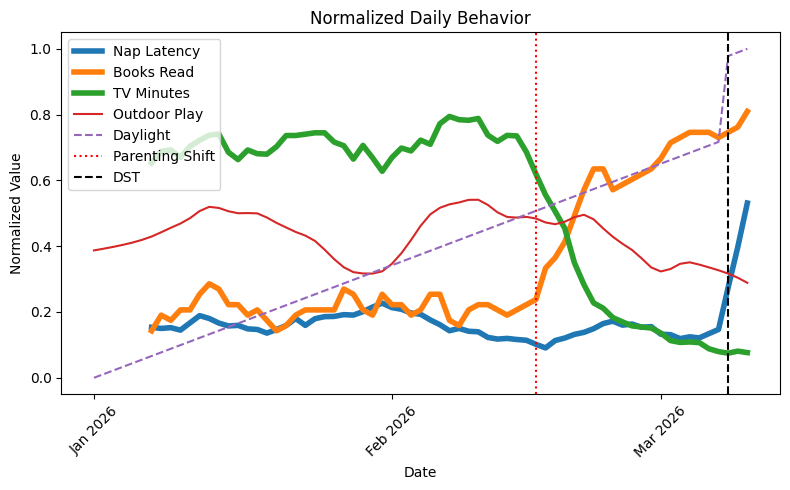

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

np.random.seed(4364564)

def generate_data(start="2026-01-01", end="2026-03-10"):

    dates = pd.date_range(start, end)

    parenting_shift = pd.Timestamp("2026-02-16")
    dst_shift = pd.Timestamp("2026-03-08")

    # daylight seasonal increase
    daylight = np.linspace(9*60, 12*60, len(dates))

    outdoor = []
    nap_duration = []
    nap_latency = []
    books = []
    tv = []
    rain = []

    for d in dates:

        # ----------------
        # Weather
        # ----------------
        rainy = np.random.rand() < 0.65
        rain.append(rainy)

        if rainy:
            outdoor_play = np.random.normal(30,4)
        else:
            outdoor_play = np.random.normal(45,5)

        outdoor.append(max(outdoor_play,0))

        # ----------------
        # Nap duration stable
        # ----------------
        nap_duration.append(np.random.normal(125,8))

        # ----------------
        # Parenting shift
        # ----------------
        if d < parenting_shift:

            tv_minutes = np.random.normal(65,8)
            books_read = np.random.poisson(2)

        else:

            days = (d - parenting_shift).days

            tv_minutes = 35 - days*0.5 + np.random.normal(0,3)
            books_read = 5 + int(days*0.1) + np.random.poisson(1)

        tv.append(max(tv_minutes,0))
        books.append(books_read)

        # ----------------
        # Nap latency spike after DST
        # ----------------
        if d < dst_shift:

            latency = 10 + np.random.normal(0,.7)

        else:

            days = (d - dst_shift).days
            latency = 18 + days*0.25 + np.random.normal(0,.4)

        nap_latency.append(latency)

    df = pd.DataFrame({
        "date":dates,
        "daylight_min":daylight,
        "outdoor_play_min":outdoor,
        "nap_duration_min":nap_duration,
        "nap_latency_min":nap_latency,
        "books_read":books,
        "tv_minutes":tv,
        "rain":rain
    })

    # DST daylight jump
    df.loc[df["date"] >= dst_shift,"daylight_min"] += 60

    return df


df = generate_data()

# -----------------------------
# Normalize for plotting
# -----------------------------

normalized = df.copy()

cols = [
    "daylight_min",
    "outdoor_play_min",
    "nap_latency_min",
    "books_read",
    "tv_minutes"
]

for c in cols:
    normalized[c+"_norm"] = (df[c]-df[c].min())/(df[c].max()-df[c].min())


# -----------------------------
# Trends
# -----------------------------

res_outdoor = STL(normalized["outdoor_play_min_norm"],period=7).fit()

latency_trend = normalized["nap_latency_min_norm"].rolling(7).mean()
books_trend = normalized["books_read_norm"].rolling(7).mean()
tv_trend = normalized["tv_minutes_norm"].rolling(7).mean()

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(df["date"], latency_trend,label="Nap Latency",linewidth=4)
plt.plot(df["date"], books_trend,label="Books Read", linewidth=4)
plt.plot(df["date"], tv_trend,label="TV Minutes", linewidth=4)
plt.plot(df["date"], res_outdoor.trend,label="Outdoor Play")
plt.plot(df["date"], normalized["daylight_min_norm"],label="Daylight",linestyle="--")

plt.axvline(pd.Timestamp("2026-02-16"),color="red",linestyle=":",label="Parenting Shift")
plt.axvline(pd.Timestamp("2026-03-08"),color="black",linestyle="--",label="DST")

months = pd.date_range(df.date.min(),df.date.max(),freq="MS")

plt.xticks(months,[d.strftime("%b %Y") for d in months],rotation=45)

plt.title("Normalized Daily Behavior")
plt.xlabel("Date")
plt.ylabel("Normalized Value")

plt.legend()
plt.tight_layout()
plt.savefig('DST_spring.png')
plt.show()

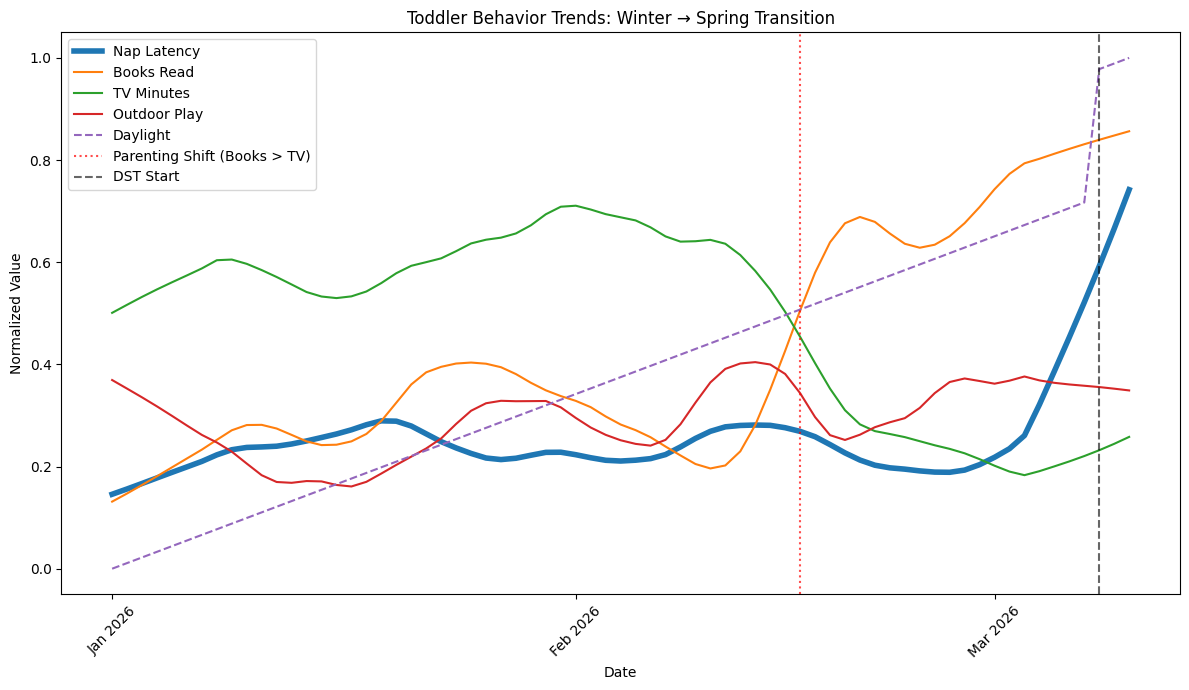

In [33]:
# ---------------------------------------
# Visualization
# ---------------------------------------

plt.figure(figsize=(12,7))

plt.plot(df["date"],res_latency.trend,label="Nap Latency",linewidth=4)
plt.plot(df["date"],res_books.trend,label="Books Read")
plt.plot(df["date"],res_tv.trend,label="TV Minutes")
plt.plot(df["date"],res_outdoor.trend,label="Outdoor Play")
plt.plot(df["date"],daylight,label="Daylight",linestyle="--")

plt.axvline(
    pd.Timestamp("2026-02-16"),
    linestyle=":",
    color="red",
    alpha=.7,
    label="Parenting Shift (Books > TV)"
)

plt.axvline(
    pd.Timestamp("2026-03-08"),
    linestyle="--",
    color="black",
    alpha=.6,
    label="DST Start"
)

months = pd.date_range(df.date.min(),df.date.max(),freq="MS")

plt.xticks(
    months,
    [d.strftime("%b %Y") for d in months],
    rotation=45
)

plt.title("Toddler Behavior Trends: Winter → Spring Transition")
plt.xlabel("Date")
plt.ylabel("Normalized Value")

plt.legend()
plt.tight_layout()

plt.show()